# 🏦 Prêt à Dépenser — Scoring Crédit
## Étape 1 : Préparation, Nettoyage et Enrichissement des Données

**Objectif :** Produire un dataset propre, fusionné et enrichi, prêt pour l'entraînement du modèle de scoring.

| Étape | Description |
|-------|-------------|
| 0 | Configuration & imports |
| 1 | Chargement des données |
| 2 | Inspection qualité (doublons, types, valeurs manquantes) |
| 3 | Feature engineering par table satellite |
| 4 | Fusion finale sur `SK_ID_CURR` |
| 5 | Feature engineering global (ratios métier) |
| 6 | Encodage & imputation |
| 7 | Analyse du déséquilibre des classes |
| 8 | Sauvegarde du dataset final |

> **Données :** Placer les fichiers CSV Kaggle [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) dans le dossier `./data/`


---
## ⚙️ 0. Configuration & Imports

In [4]:
# Installation des dépendances (décommenter si besoin)
# !pip install pandas numpy matplotlib seaborn scikit-learn missingno lightgbm

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

# ── Chemins ───────────────────────────────────────────────────────
DATA_DIR    = "../data"
OUTPUT_DIR  = "../output"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Style graphique ───────────────────────────────────────────────
PALETTE = {"0 - Bon client": "#1D9E75", "1 - Défaut": "#D85A30"}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight"})

print("✅ Configuration OK")
print(f"   DATA_DIR    → {os.path.abspath(DATA_DIR)}")
print(f"   OUTPUT_DIR  → {os.path.abspath(OUTPUT_DIR)}")


✅ Configuration OK
   DATA_DIR    → /Users/diagabatekoffi/PycharmProjects/MlProject/data
   OUTPUT_DIR  → /Users/diagabatekoffi/PycharmProjects/MlProject/output


---
## 📂 1. Chargement des données

Le dataset Home Credit est composé de **7 fichiers CSV** reliés par deux clés :
- `SK_ID_CURR` → identifiant client (clé principale)
- `SK_ID_PREV` → identifiant de prêt précédent (clé secondaire)


In [5]:
def load_csv(filename, nrows=None):
    """Charge un CSV depuis DATA_DIR avec affichage des dimensions."""
    path = os.path.join(DATA_DIR, filename)
    df = pd.read_csv(path, nrows=nrows)
    print(f"  ✓  {filename:<45}  {df.shape[0]:>8,} lignes  ×  {df.shape[1]:>4} colonnes")
    return df

print("Chargement des fichiers :")
print("-" * 65)
app_train      = load_csv("application_train.csv")
app_test       = load_csv("application_test.csv")
bureau         = load_csv("bureau.csv")
bureau_balance = load_csv("bureau_balance.csv")
prev_app       = load_csv("previous_application.csv")
pos_cash       = load_csv("POS_CASH_balance.csv")
installments   = load_csv("installments_payments.csv")
credit_card    = load_csv("credit_card_balance.csv")
print("-" * 65)
print(f"\n→ Table principale : {app_train.shape[0]:,} clients")
print(f"  TARGET=1 (défaut) : {app_train['TARGET'].sum():,}  ({app_train['TARGET'].mean()*100:.1f}%)")


Chargement des fichiers :
-----------------------------------------------------------------
  ✓  application_train.csv                           307,511 lignes  ×   122 colonnes
  ✓  application_test.csv                             48,744 lignes  ×   121 colonnes
  ✓  bureau.csv                                     1,716,428 lignes  ×    17 colonnes
  ✓  bureau_balance.csv                             27,299,925 lignes  ×     3 colonnes
  ✓  previous_application.csv                       1,670,214 lignes  ×    37 colonnes
  ✓  POS_CASH_balance.csv                           10,001,358 lignes  ×     8 colonnes
  ✓  installments_payments.csv                      13,605,401 lignes  ×     8 colonnes
  ✓  credit_card_balance.csv                        3,840,312 lignes  ×    23 colonnes
-----------------------------------------------------------------

→ Table principale : 307,511 clients
  TARGET=1 (défaut) : 24,825  (8.1%)


In [6]:
# Aperçu de la table principale
app_train.head(3)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# Types et premières statistiques
app_train.info(verbose=False, show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


---
## 🔍 2. Inspection qualité — `application_train`

On vérifie : doublons, types de colonnes, taux de valeurs manquantes et valeurs aberrantes connues du dataset.


In [8]:
# ── 2a. Doublons ─────────────────────────────────────────────────
n_dup = app_train.duplicated(subset="SK_ID_CURR").sum()
print(f"Doublons sur SK_ID_CURR : {n_dup}")
if n_dup > 0:
    app_train = app_train.drop_duplicates(subset="SK_ID_CURR")
    print(f"→ {n_dup} doublon(s) supprimé(s)")
else:
    print("→ Aucun doublon détecté ✓")


Doublons sur SK_ID_CURR : 0
→ Aucun doublon détecté ✓


In [9]:
# ── 2b. Types de colonnes ────────────────────────────────────────
num_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = app_train.select_dtypes(include="object").columns.tolist()

print(f"Colonnes numériques   : {len(num_cols)}")
print(f"Colonnes catégorielles: {len(cat_cols)}")
print(f"\nExemples catégorielles : {cat_cols[:8]}")


Colonnes numériques   : 106
Colonnes catégorielles: 16

Exemples catégorielles : ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS']


In [10]:
# ── 2c. Taux de valeurs manquantes ───────────────────────────────
missing = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_df = missing[missing > 0].reset_index()
missing_df.columns = ["Colonne", "% Manquants"]
missing_df["% Manquants"] = missing_df["% Manquants"].round(2)

print(f"Colonnes avec valeurs manquantes : {len(missing_df)}")
print(f"  > 60% : {(missing_df['% Manquants'] > 60).sum()}")
print(f"  > 40% : {(missing_df['% Manquants'] > 40).sum()}")
print(f"  > 20% : {(missing_df['% Manquants'] > 20).sum()}")
missing_df.head(15)


Colonnes avec valeurs manquantes : 67
  > 60% : 17
  > 40% : 49
  > 20% : 50


,Colonne,% Manquants
0,COMMONAREA_MEDI,69.87
1,COMMONAREA_AVG,69.87
2,COMMONAREA_MODE,69.87
3,NONLIVINGAPARTMENTS_MODE,69.43
4,NONLIVINGAPARTMENTS_AVG,69.43
5,NONLIVINGAPARTMENTS_MEDI,69.43
6,FONDKAPREMONT_MODE,68.39
7,LIVINGAPARTMENTS_MODE,68.35
8,LIVINGAPARTMENTS_AVG,68.35
9,LIVINGAPARTMENTS_MEDI,68.35


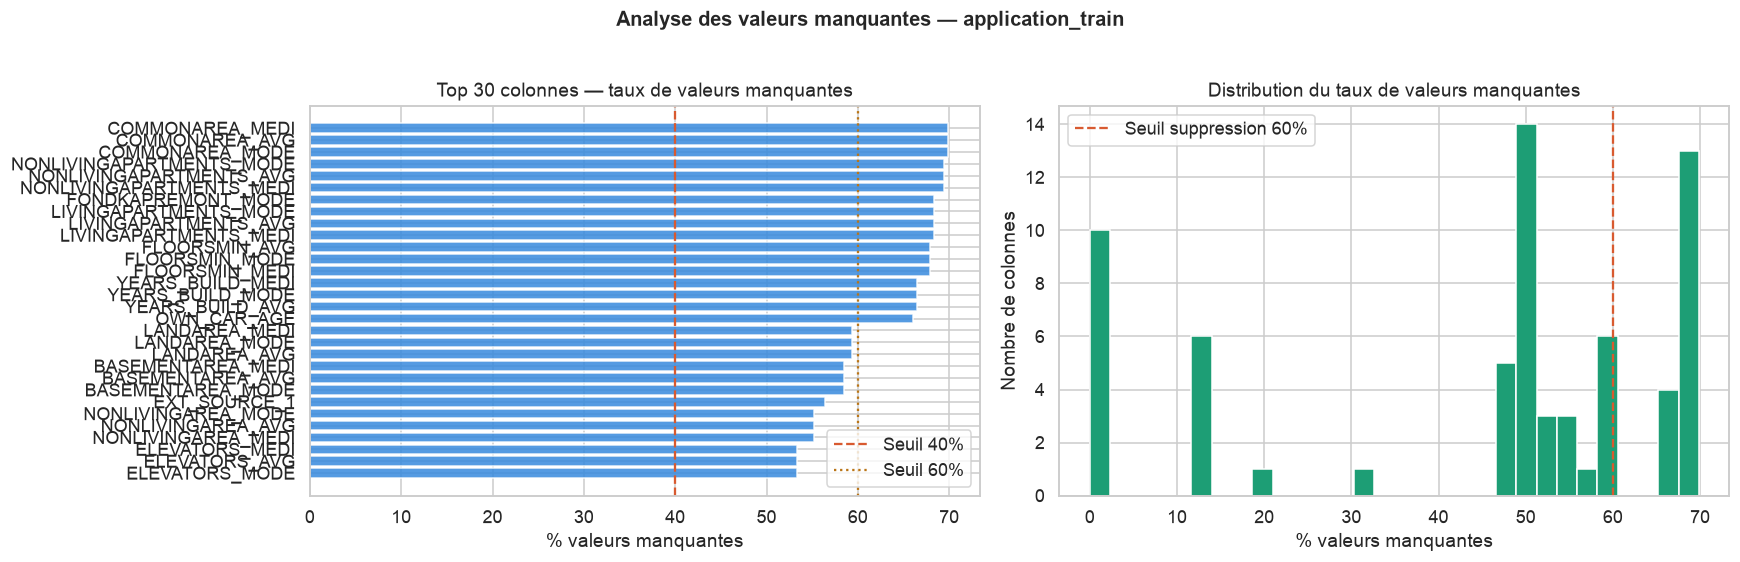

In [11]:
# ── 2d. Visualisation des valeurs manquantes ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top30 = missing[missing > 0].head(30)
axes[0].barh(top30.index[::-1], top30.values[::-1], color="#378ADD", alpha=0.85)
axes[0].set_xlabel("% valeurs manquantes")
axes[0].set_title("Top 30 colonnes — taux de valeurs manquantes")
axes[0].axvline(40, color="#D85A30", ls="--", lw=1.5, label="Seuil 40%")
axes[0].axvline(60, color="#BA7517", ls=":",  lw=1.5, label="Seuil 60%")
axes[0].legend()

axes[1].hist(missing[missing > 0], bins=30, color="#1D9E75", edgecolor="white")
axes[1].set_xlabel("% valeurs manquantes")
axes[1].set_ylabel("Nombre de colonnes")
axes[1].set_title("Distribution du taux de valeurs manquantes")
axes[1].axvline(60, color="#D85A30", ls="--", lw=1.5, label="Seuil suppression 60%")
axes[1].legend()

plt.suptitle("Analyse des valeurs manquantes — application_train", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_valeurs_manquantes.png"))
plt.show()


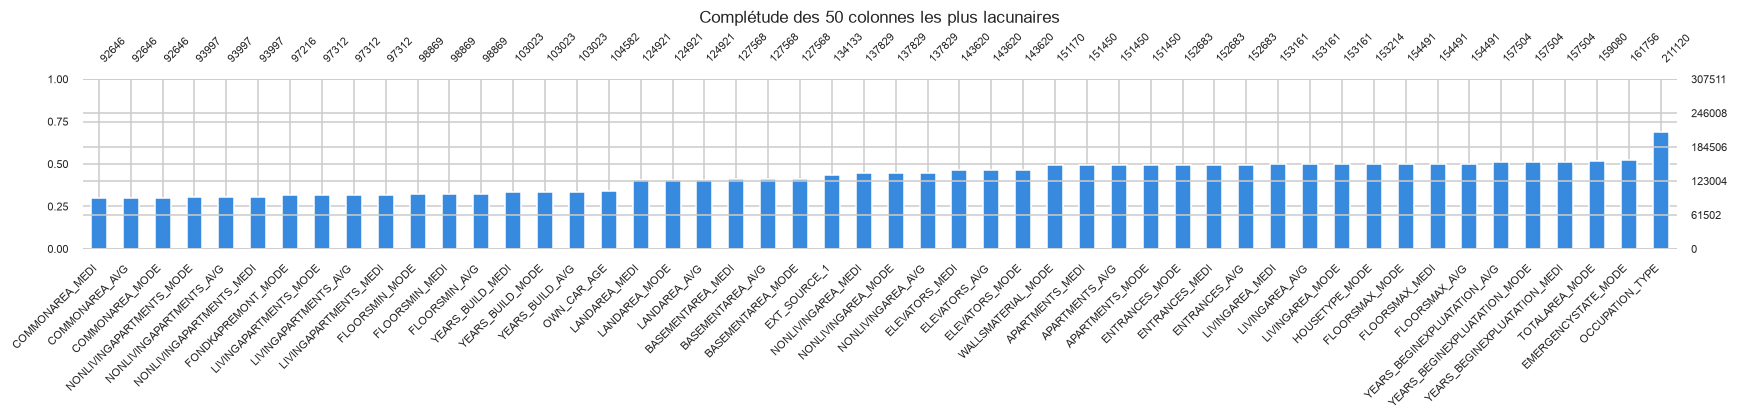

In [12]:
# ── Visualisation Missingno ───────────────────────────────────────
snapshot_cols = missing[missing > 0].head(50).index.tolist()
fig, ax = plt.subplots(figsize=(16, 4))
msno.bar(app_train[snapshot_cols], ax=ax, color="#378ADD", fontsize=7, sort="ascending")
ax.set_title("Complétude des 50 colonnes les plus lacunaires", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01b_missingno.png"))
plt.show()


In [13]:
# ── 2e. Suppression colonnes > 60% manquants ─────────────────────
# Justification : au-delà de 60%, l'imputation introduit plus de biais
# qu'elle n'apporte d'information utile au modèle.
cols_drop_missing = missing[missing > 60].index.tolist()
print(f"Colonnes supprimées (> 60% manquants) : {len(cols_drop_missing)}")
print(cols_drop_missing)

app_train = app_train.drop(columns=cols_drop_missing)
app_test  = app_test.drop(columns=[c for c in cols_drop_missing if c in app_test.columns])
print(f"\nShape après suppression : {app_train.shape}")


Colonnes supprimées (> 60% manquants) : 17
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE']

Shape après suppression : (307511, 105)


In [14]:
# ── 2f. Correction des valeurs aberrantes connues ─────────────────
# DAYS_BIRTH    : jours négatifs (normal) → convertir en âge positif
# DAYS_EMPLOYED : 365243 = valeur sentinelle "non employé" → NaN

for df in [app_train, app_test]:
    df["AGE_YEARS"]      = (-df["DAYS_BIRTH"] / 365).round(1)
    df["DAYS_EMPLOYED"]  = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    df["EMPLOYED_YEARS"] = (-df["DAYS_EMPLOYED"] / 365).clip(lower=0)

print("✓ AGE_YEARS créé")
print("✓ DAYS_EMPLOYED nettoyé (365243 → NaN)")
print("✓ EMPLOYED_YEARS créé")
print(f"\nÂge moyen : {app_train['AGE_YEARS'].mean():.1f} ans")
print(f"Ancienneté emploi moyenne : {app_train['EMPLOYED_YEARS'].mean():.1f} ans")


✓ AGE_YEARS créé
✓ DAYS_EMPLOYED nettoyé (365243 → NaN)
✓ EMPLOYED_YEARS créé

Âge moyen : 43.9 ans
Ancienneté emploi moyenne : 6.5 ans


---
## 🔧 3. Feature Engineering — Tables satellites

Chaque table satellite est agrégée par `SK_ID_CURR` (ou `SK_ID_PREV` puis `SK_ID_CURR`).
On calcule des statistiques descriptives (mean, max, min, sum, std, count) et des **indicateurs métier** spécifiques.


In [15]:
def agg_table(df, group_col, prefix, agg_funcs=None):
    """
    Agrège une DataFrame par group_col.
    Produit des features nommées PREFIX_COLONNE_STAT.
    """
    if agg_funcs is None:
        agg_funcs = ["mean", "max", "min", "sum", "std", "count"]
    num_df  = df.select_dtypes(include=[np.number]).drop(columns=[group_col], errors="ignore")
    grouped = num_df.groupby(df[group_col]).agg(agg_funcs)
    grouped.columns = [f"{prefix}_{col}_{func}".upper() for col, func in grouped.columns]
    return grouped.reset_index()

print("✓ Fonction agg_table définie")


✓ Fonction agg_table définie


In [16]:
# ── 3a. bureau + bureau_balance ──────────────────────────────────
print("=== [3a] bureau + bureau_balance ===")

# Agrégation bureau_balance par SK_ID_BUREAU
bb_agg = agg_table(bureau_balance, "SK_ID_BUREAU", "BB")

# Encodage ordinal du statut de remboursement
# C=Clôturé=0 | 0=Pas de DPD | 1..5=retard en mois | X=inconnu
status_map = {"C": 0, "X": np.nan,
              "0": 0, "1": 1, "2": 2, "3": 3, "4": 4, "5": 5}
bureau_balance["STATUS_NUM"] = bureau_balance["STATUS"].map(status_map)
bb_status = bureau_balance.groupby("SK_ID_BUREAU")["STATUS_NUM"].agg(
    BB_STATUS_MEAN="mean",
    BB_STATUS_MAX="max",
    BB_N_OVERDUE=lambda x: (x > 0).sum()
).reset_index()
bb_agg = bb_agg.merge(bb_status, on="SK_ID_BUREAU", how="left")

# Enrichissement bureau avec bb_agg, puis agrégation par SK_ID_CURR
bureau_enriched = bureau.merge(bb_agg, on="SK_ID_BUREAU", how="left")
bureau_agg = agg_table(bureau_enriched, "SK_ID_CURR", "BUR")

# Features métier : crédits actifs, nombre total de crédits
credit_active = (bureau.groupby("SK_ID_CURR")
                       .apply(lambda x: (x["CREDIT_ACTIVE"] == "Active").sum())
                       .reset_index(name="BUR_N_ACTIVE_CREDITS"))
credit_counts = bureau.groupby("SK_ID_CURR").size().reset_index(name="BUR_N_CREDITS_TOTAL")

bureau_agg = bureau_agg.merge(credit_active, on="SK_ID_CURR", how="left")
bureau_agg = bureau_agg.merge(credit_counts, on="SK_ID_CURR", how="left")

print(f"✓ bureau_agg  : {bureau_agg.shape}")
bureau_agg.head(3)


=== [3a] bureau + bureau_balance ===
✓ bureau_agg  : (305811, 135)


,SK_ID_CURR,BUR_SK_ID_BUREAU_MEAN,BUR_SK_ID_BUREAU_MAX,BUR_SK_ID_BUREAU_MIN,BUR_SK_ID_BUREAU_SUM,BUR_SK_ID_BUREAU_STD,BUR_SK_ID_BUREAU_COUNT,BUR_DAYS_CREDIT_MEAN,BUR_DAYS_CREDIT_MAX,BUR_DAYS_CREDIT_MIN,...,BUR_BB_STATUS_MAX_STD,BUR_BB_STATUS_MAX_COUNT,BUR_BB_N_OVERDUE_MEAN,BUR_BB_N_OVERDUE_MAX,BUR_BB_N_OVERDUE_MIN,BUR_BB_N_OVERDUE_SUM,BUR_BB_N_OVERDUE_STD,BUR_BB_N_OVERDUE_COUNT,BUR_N_ACTIVE_CREDITS,BUR_N_CREDITS_TOTAL
0,100001,5896633.000,5896636,5896630,41276431,2.160247,7,-735.00,-49,-1572,...,0.377964,7,0.142857,1.0,0.0,1.0,0.377964,7,3,7
1,100002,6153272.125,6158909,6113835,49226177,15935.004993,8,-874.00,-103,-1437,...,0.462910,8,3.375000,6.0,0.0,27.0,2.875388,8,2,8
2,100003,5885878.500,5885880,5885877,23543514,1.290994,4,-1400.75,-606,-2586,...,NaN,0,NaN,NaN,NaN,0.0,NaN,0,1,4


In [17]:
# ── 3b. previous_application ─────────────────────────────────────
print("=== [3b] previous_application ===")

# Nettoyage valeur sentinelle 365243
for col in ["DAYS_FIRST_DRAWING", "DAYS_FIRST_DUE", "DAYS_LAST_DUE",
            "DAYS_LAST_DUE_1ST_VERSION", "DAYS_TERMINATION"]:
    if col in prev_app.columns:
        prev_app[col] = prev_app[col].replace(365243, np.nan)

prev_agg = agg_table(prev_app, "SK_ID_CURR", "PREV")

# Taux d'approbation : indicateur fort du profil de risque
prev_meta = prev_app.groupby("SK_ID_CURR").agg(
    PREV_N_APPLICATIONS=("SK_ID_PREV", "count"),
    PREV_N_APPROVED=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    PREV_N_REFUSED=("NAME_CONTRACT_STATUS",  lambda x: (x == "Refused").sum()),
).reset_index()
prev_meta["PREV_APPROVAL_RATE"] = (
    prev_meta["PREV_N_APPROVED"] / prev_meta["PREV_N_APPLICATIONS"].clip(lower=1)
)
prev_agg = prev_agg.merge(prev_meta, on="SK_ID_CURR", how="left")

print(f"✓ prev_agg  : {prev_agg.shape}")
prev_agg.head(3)


=== [3b] previous_application ===
✓ prev_agg  : (338857, 125)


,SK_ID_CURR,PREV_SK_ID_PREV_MEAN,PREV_SK_ID_PREV_MAX,PREV_SK_ID_PREV_MIN,PREV_SK_ID_PREV_SUM,PREV_SK_ID_PREV_STD,PREV_SK_ID_PREV_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_ANNUITY_MIN,...,PREV_NFLAG_INSURED_ON_APPROVAL_MEAN,PREV_NFLAG_INSURED_ON_APPROVAL_MAX,PREV_NFLAG_INSURED_ON_APPROVAL_MIN,PREV_NFLAG_INSURED_ON_APPROVAL_SUM,PREV_NFLAG_INSURED_ON_APPROVAL_STD,PREV_NFLAG_INSURED_ON_APPROVAL_COUNT,PREV_N_APPLICATIONS,PREV_N_APPROVED,PREV_N_REFUSED,PREV_APPROVAL_RATE
0,100001,1.369693e+06,1369693,1369693,1369693,NaN,1,3951.000,3951.000,3951.000,...,0.000000,0.0,0.0,0.0,NaN,1,1,1,0,1.0
1,100002,1.038818e+06,1038818,1038818,1038818,NaN,1,9251.775,9251.775,9251.775,...,0.000000,0.0,0.0,0.0,NaN,1,1,1,0,1.0
2,100003,2.281150e+06,2636178,1810518,6843451,424796.348991,3,56553.990,98356.995,6737.310,...,0.666667,1.0,0.0,2.0,0.57735,3,3,3,0,1.0


In [18]:
# ── 3c. POS_CASH_balance ─────────────────────────────────────────
print("=== [3c] POS_CASH_balance ===")

pos_agg = agg_table(pos_cash, "SK_ID_CURR", "POS")
pos_meta = pos_cash.groupby("SK_ID_CURR").agg(
    POS_N_MONTHS  =("MONTHS_BALANCE", "count"),
    POS_N_OVERDUE =("SK_DPD", lambda x: (x > 0).sum()),
    POS_MAX_DPD   =("SK_DPD", "max"),
).reset_index()
pos_agg = pos_agg.merge(pos_meta, on="SK_ID_CURR", how="left")

print(f"✓ pos_agg : {pos_agg.shape}")
pos_agg.head(3)


=== [3c] POS_CASH_balance ===
✓ pos_agg : (337252, 40)


,SK_ID_CURR,POS_SK_ID_PREV_MEAN,POS_SK_ID_PREV_MAX,POS_SK_ID_PREV_MIN,POS_SK_ID_PREV_SUM,POS_SK_ID_PREV_STD,POS_SK_ID_PREV_COUNT,POS_MONTHS_BALANCE_MEAN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_MIN,...,POS_SK_DPD_COUNT,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_SK_DPD_DEF_MIN,POS_SK_DPD_DEF_SUM,POS_SK_DPD_DEF_STD,POS_SK_DPD_DEF_COUNT,POS_N_MONTHS,POS_N_OVERDUE,POS_MAX_DPD
0,100001,1.584045e+06,1851984,1369693,14256401,254189.675833,9,-72.555556,-53,-96,...,9,0.777778,7,0,7,2.333333,9,9,1,7
1,100002,1.038818e+06,1038818,1038818,19737542,0.000000,19,-10.000000,-1,-19,...,19,0.000000,0,0,0,0.000000,19,19,0,0
2,100003,2.297665e+06,2636178,1810518,64334628,329593.011850,28,-43.785714,-18,-77,...,28,0.000000,0,0,0,0.000000,28,28,0,0


In [19]:
# ── 3d. installments_payments ────────────────────────────────────
print("=== [3d] installments_payments ===")

# Features de comportement de paiement
installments["PAYMENT_DIFF"] = installments["AMT_PAYMENT"] - installments["AMT_INSTALMENT"]
installments["DAYS_LATE"]    = installments["DAYS_ENTRY_PAYMENT"] - installments["DAYS_INSTALMENT"]
installments["IS_LATE"]      = (installments["DAYS_LATE"] > 0).astype(int)
installments["IS_UNDERPAID"] = (installments["PAYMENT_DIFF"] < 0).astype(int)

ins_agg = agg_table(installments, "SK_ID_CURR", "INS")
ins_meta = installments.groupby("SK_ID_CURR").agg(
    INS_N_PAYMENTS    =("AMT_PAYMENT", "count"),
    INS_N_LATE        =("IS_LATE", "sum"),
    INS_LATE_RATE     =("IS_LATE", "mean"),
    INS_N_UNDERPAID   =("IS_UNDERPAID", "sum"),
    INS_MAX_DAYS_LATE =("DAYS_LATE", "max"),
).reset_index()
ins_agg = ins_agg.merge(ins_meta, on="SK_ID_CURR", how="left")

print(f"✓ ins_agg : {ins_agg.shape}")
ins_agg.head(3)


=== [3d] installments_payments ===
✓ ins_agg : (339587, 72)


,SK_ID_CURR,INS_SK_ID_PREV_MEAN,INS_SK_ID_PREV_MAX,INS_SK_ID_PREV_MIN,INS_SK_ID_PREV_SUM,INS_SK_ID_PREV_STD,INS_SK_ID_PREV_COUNT,INS_NUM_INSTALMENT_VERSION_MEAN,INS_NUM_INSTALMENT_VERSION_MAX,INS_NUM_INSTALMENT_VERSION_MIN,...,INS_IS_UNDERPAID_MAX,INS_IS_UNDERPAID_MIN,INS_IS_UNDERPAID_SUM,INS_IS_UNDERPAID_STD,INS_IS_UNDERPAID_COUNT,INS_N_PAYMENTS,INS_N_LATE,INS_LATE_RATE,INS_N_UNDERPAID,INS_MAX_DAYS_LATE
0,100001,1.576389e+06,1851984,1369693,11034724,257795.383246,7,1.142857,2.0,1.0,...,0,0,0,0.0,7,7,1,0.142857,0,11.0
1,100002,1.038818e+06,1038818,1038818,19737542,0.000000,19,1.052632,2.0,1.0,...,0,0,0,0.0,19,19,0,0.000000,0,-12.0
2,100003,2.290070e+06,2636178,1810518,57251754,320488.923470,25,1.040000,2.0,1.0,...,0,0,0,0.0,25,25,0,0.000000,0,-1.0


In [20]:
# ── 3e. credit_card_balance ───────────────────────────────────────
print("=== [3e] credit_card_balance ===")

# Taux d'utilisation carte : signal fort de stress financier
credit_card["UTILIZATION_RATE"] = (
    credit_card["AMT_BALANCE"] /
    credit_card["AMT_CREDIT_LIMIT_ACTUAL"].replace(0, np.nan)
)
cc_agg = agg_table(credit_card, "SK_ID_CURR", "CC")
cc_meta = credit_card.groupby("SK_ID_CURR").agg(
    CC_N_MONTHS        =("MONTHS_BALANCE", "count"),
    CC_N_DRAWINGS      =("CNT_DRAWINGS_CURRENT", "sum"),
    CC_N_OVERDUE       =("SK_DPD", lambda x: (x > 0).sum()),
    CC_MEAN_UTILIZATION=("UTILIZATION_RATE", "mean"),
    CC_MAX_UTILIZATION =("UTILIZATION_RATE", "max"),
).reset_index()
cc_agg = cc_agg.merge(cc_meta, on="SK_ID_CURR", how="left")

print(f"✓ cc_agg : {cc_agg.shape}")
cc_agg.head(3)


=== [3e] credit_card_balance ===
✓ cc_agg : (103558, 138)


,SK_ID_CURR,CC_SK_ID_PREV_MEAN,CC_SK_ID_PREV_MAX,CC_SK_ID_PREV_MIN,CC_SK_ID_PREV_SUM,CC_SK_ID_PREV_STD,CC_SK_ID_PREV_COUNT,CC_MONTHS_BALANCE_MEAN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_MIN,...,CC_UTILIZATION_RATE_MAX,CC_UTILIZATION_RATE_MIN,CC_UTILIZATION_RATE_SUM,CC_UTILIZATION_RATE_STD,CC_UTILIZATION_RATE_COUNT,CC_N_MONTHS,CC_N_DRAWINGS,CC_N_OVERDUE,CC_MEAN_UTILIZATION,CC_MAX_UTILIZATION
0,100006,1489396.0,1489396,1489396,8936376,0.0,6,-3.5,-1,-6,...,0.00000,0.0,0.000000,0.000000,6,6,0,0,0.000000,0.00000
1,100011,1843384.0,1843384,1843384,136410416,0.0,74,-38.5,-2,-75,...,1.05000,0.0,22.398201,0.378485,74,74,4,0,0.302678,1.05000
2,100013,2038692.0,2038692,2038692,195714432,0.0,96,-48.5,-1,-96,...,1.02489,0.0,11.068903,0.274523,96,96,23,1,0.115301,1.02489


---
## 🔗 4. Fusion finale sur `SK_ID_CURR`

On réalise des **left joins** sur la table principale pour ne perdre aucun client.
Une assertion vérifie l'absence de perte de lignes après chaque merge.


In [21]:
def full_merge(app_df, label="train"):
    """Fusionne toutes les tables satellites sur SK_ID_CURR."""
    df = app_df.copy()
    n0 = len(df)
    df = df.merge(bureau_agg, on="SK_ID_CURR", how="left")
    df = df.merge(prev_agg,   on="SK_ID_CURR", how="left")
    df = df.merge(pos_agg,    on="SK_ID_CURR", how="left")
    df = df.merge(ins_agg,    on="SK_ID_CURR", how="left")
    df = df.merge(cc_agg,     on="SK_ID_CURR", how="left")
    assert len(df) == n0, f"❌ Perte de lignes lors du merge ({label}) !"
    print(f"✓ {label:<6} : {df.shape[0]:>8,} lignes × {df.shape[1]:>5,} colonnes  (0 perte)")
    return df

print("Fusion en cours...")
train = full_merge(app_train, "train")
test  = full_merge(app_test,  "test")
print("\n✅ Fusion terminée sans perte de données")


Fusion en cours...
✓ train  :  307,511 lignes ×   612 colonnes  (0 perte)
✓ test   :   48,744 lignes ×   611 colonnes  (0 perte)

✅ Fusion terminée sans perte de données


In [22]:
def add_features(df):
    """Ajoute des ratios et indicateurs de risque métier."""
    eps = 1e-6  # évite les divisions par zéro

    # ── Ratios financiers ─────────────────────────────────────────
    df["CREDIT_TO_INCOME"]  = df["AMT_CREDIT"]       / (df["AMT_INCOME_TOTAL"] + eps)
    df["ANNUITY_TO_INCOME"] = df["AMT_ANNUITY"]      / (df["AMT_INCOME_TOTAL"] + eps)
    df["GOODS_TO_CREDIT"]   = df["AMT_GOODS_PRICE"]  / (df["AMT_CREDIT"] + eps)
    df["INCOME_PER_PERSON"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"].clip(lower=1)

    # ── Ratios temporels ──────────────────────────────────────────
    df["EMPLOYED_TO_AGE"]   = df["EMPLOYED_YEARS"]   / (df["AGE_YEARS"] + eps)
    df["CREDIT_TO_AGE"]     = df["AMT_CREDIT"]       / (df["AGE_YEARS"] + eps)

    # ── Scores externes (très prédictifs dans Home Credit) ────────
    ext_cols = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
                if c in df.columns]
    if ext_cols:
        df["EXT_SOURCE_MEAN"] = df[ext_cols].mean(axis=1)
        df["EXT_SOURCE_PROD"] = df[ext_cols].prod(axis=1)
        df["EXT_SOURCE_STD"]  = df[ext_cols].std(axis=1)
        df["EXT_SOURCE_MIN"]  = df[ext_cols].min(axis=1)

    # ── Indicateurs de risque comportemental ─────────────────────
    if "INS_LATE_RATE" in df.columns:
        df["HIGH_LATE_RISK"] = (df["INS_LATE_RATE"] > 0.2).astype(int)
    if "CC_MEAN_UTILIZATION" in df.columns:
        df["HIGH_UTIL_RISK"] = (df["CC_MEAN_UTILIZATION"] > 0.8).astype(int)

    return df

train = add_features(train)
test  = add_features(test)
print(f"✓ Features créées. Shape train : {train.shape}")

# Aperçu des nouvelles features
new_feats = ["CREDIT_TO_INCOME","ANNUITY_TO_INCOME","EXT_SOURCE_MEAN",
             "EMPLOYED_TO_AGE","HIGH_LATE_RISK","HIGH_UTIL_RISK"]
train[[f for f in new_feats if f in train.columns]].describe().round(3)


✓ Features créées. Shape train : (307511, 624)


,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,EXT_SOURCE_MEAN,EMPLOYED_TO_AGE,HIGH_LATE_RISK,HIGH_UTIL_RISK
count,307511.000,307499.000,307339.000,252137.000,307511.000,307511.000
mean,3.958,0.181,0.509,0.157,0.122,0.034
std,2.690,0.095,0.150,0.134,0.327,0.181
min,0.005,0.000,0.000,-0.000,0.000,0.000
25%,2.019,0.115,0.414,0.056,0.000,0.000
50%,3.265,0.163,0.525,0.119,0.000,0.000
75%,5.160,0.229,0.623,0.219,0.000,0.000
max,84.737,1.876,0.879,0.729,1.000,1.000


---
## 🧹 6. Encodage & Imputation

**Stratégie d'encodage :**
- Variables **binaires** (2 modalités) → `LabelEncoder`
- Variables **nominales** (> 2 modalités) → `pd.get_dummies` (one-hot, `drop_first=True` pour éviter le dummy trap)

**Stratégie d'imputation :**
- **Médiane** : robuste aux outliers, adaptée aux variables financières asymétriques
- `fit` sur train uniquement, `transform` sur test → **évite le data leakage**


In [23]:
# ── Séparation target & identifiants ─────────────────────────────
TARGET   = train["TARGET"]
SK_TRAIN = train["SK_ID_CURR"]
SK_TEST  = test["SK_ID_CURR"]

train = train.drop(columns=["TARGET", "SK_ID_CURR"])
test  = test.drop(columns=["SK_ID_CURR"], errors="ignore")

# ── Encodage LabelEncoder (binaires) ─────────────────────────────
cat_cols_all = train.select_dtypes(include="object").columns.tolist()
binary_cats  = [c for c in cat_cols_all if train[c].nunique() == 2]

le = LabelEncoder()
for col in binary_cats:
    combined = pd.concat([train[col], test[col]], axis=0).astype(str)
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print(f"✓ LabelEncoder : {len(binary_cats)} variables binaires encodées")

# ── Encodage One-Hot (nominales) ──────────────────────────────────
nominal_cats = [c for c in cat_cols_all if c not in binary_cats]
train = pd.get_dummies(train, columns=nominal_cats, drop_first=True)
test  = pd.get_dummies(test,  columns=nominal_cats, drop_first=True)

# Alignement colonnes train / test (le one-hot peut créer des colonnes différentes)
train, test = train.align(test, join="left", axis=1, fill_value=0)
print(f"✓ One-Hot : {len(nominal_cats)} variables nominales encodées")
print(f"✓ Alignement train/test effectué")
print(f"  Shape train : {train.shape} | test : {test.shape}")


✓ LabelEncoder : 4 variables binaires encodées
✓ One-Hot : 11 variables nominales encodées
✓ Alignement train/test effectué
  Shape train : (307511, 728) | test : (48744, 728)


In [24]:

# ── Remplacement des infinis ──────────────────────────────────────
num_cols_train = train.select_dtypes(include=[np.number]).columns
n_inf = np.isinf(train[num_cols_train].values).sum()
print(f"Valeurs infinies dans train : {n_inf}")
train = train.replace([np.inf, -np.inf], np.nan)
test  = test.replace([np.inf, -np.inf], np.nan)

# ── Imputation par la médiane ─────────────────────────────────────
n_nan_before = train.isnull().sum().sum()
imputer = SimpleImputer(strategy="median")
train_imputed = pd.DataFrame(
    imputer.fit_transform(train),
    columns=train.columns, index=train.index
)
test_imputed = pd.DataFrame(
    imputer.transform(test),
    columns=test.columns, index=test.index
)
n_nan_after = train_imputed.isnull().sum().sum()
print(f"✓ Imputation médiane : {n_nan_before:,} NaN → {n_nan_after} NaN")

# Ré-attacher TARGET et IDs
train_imputed.insert(0, "SK_ID_CURR", SK_TRAIN.values)
train_imputed.insert(1, "TARGET",     TARGET.values)
test_imputed.insert(0,  "SK_ID_CURR", SK_TEST.values)

print(f"\n✅ Dataset final prêt :")
print(f"   train : {train_imputed.shape}")
print(f"   test  : {test_imputed.shape}")


Valeurs infinies dans train : 0
✓ Imputation médiane : 58,991,150 NaN → 0 NaN

✅ Dataset final prêt :
   train : (307511, 730)
   test  : (48744, 729)


---
## ⚖️ 7. Analyse du déséquilibre des classes

Le déséquilibre des classes est un enjeu majeur : les défauts représentent ~8% des cas.
Sans correction, un modèle naïf prédirait "toujours bon client" avec 92% d'accuracy
mais serait inutile métier.

**Stratégies possibles :** `class_weight`, SMOTE, under-sampling (à traiter en étape 2)


In [25]:
class_counts = TARGET.value_counts().sort_index()
class_pct    = (class_counts / len(TARGET) * 100).round(2)

print("Distribution de la variable TARGET :")
print(f"  Classe 0 — Bon client : {class_counts[0]:>8,}  ({class_pct[0]:.1f}%)")
print(f"  Classe 1 — Défaut     : {class_counts[1]:>8,}  ({class_pct[1]:.1f}%)")
print(f"  Ratio de déséquilibre : 1 pour {class_counts[0]/class_counts[1]:.0f}")
print(f"\n  → Un modèle naïf (toujours 0) aurait {class_pct[0]:.1f}% d'accuracy")
print(f"  → Mais 0% de recall sur les défauts : inutilisable métier !")


Distribution de la variable TARGET :
  Classe 0 — Bon client :  282,686  (91.9%)
  Classe 1 — Défaut     :   24,825  (8.1%)
  Ratio de déséquilibre : 1 pour 11

  → Un modèle naïf (toujours 0) aurait 91.9% d'accuracy
  → Mais 0% de recall sur les défauts : inutilisable métier !


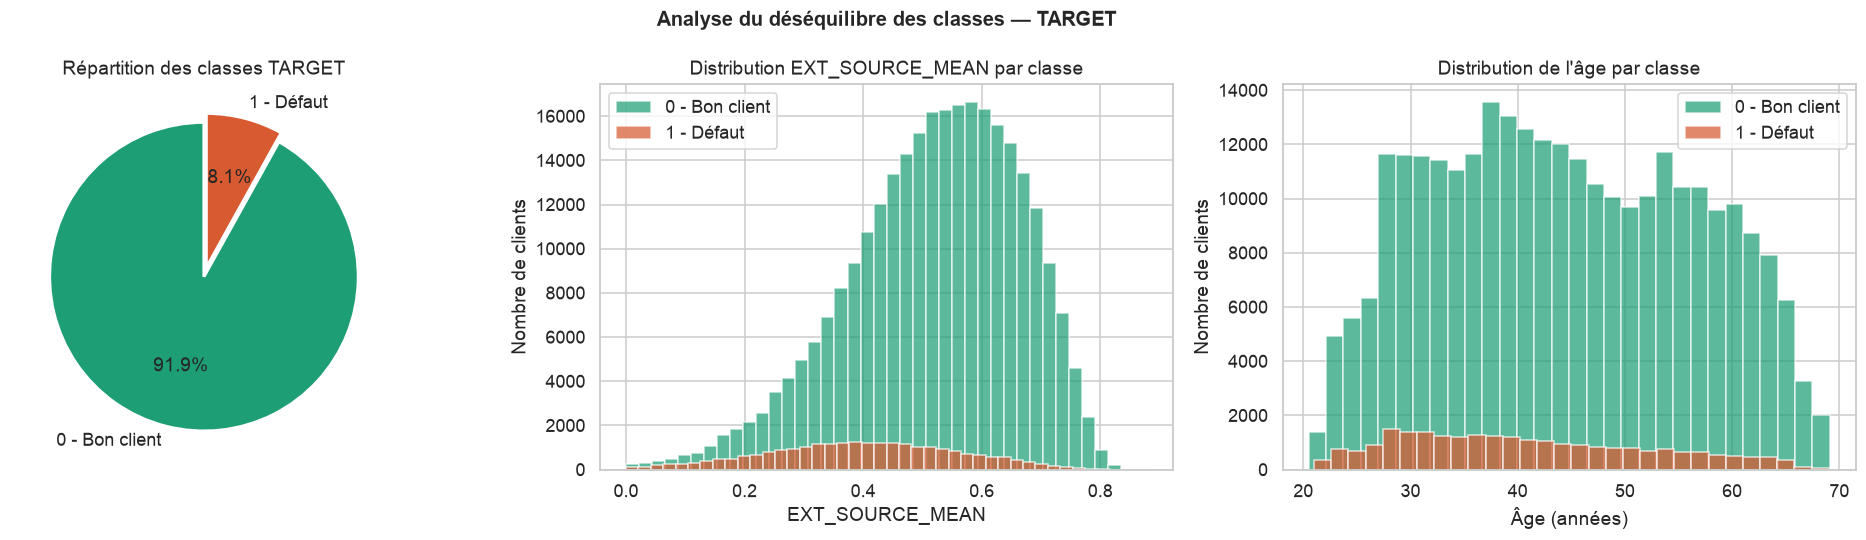

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Analyse du déséquilibre des classes — TARGET", fontsize=13, fontweight="bold")

# ── Camembert ─────────────────────────────────────────────────────
axes[0].pie(
    class_counts,
    labels=["0 - Bon client", "1 - Défaut"],
    autopct="%1.1f%%",
    colors=["#1D9E75", "#D85A30"],
    startangle=90,
    explode=(0, 0.06),
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[0].set_title("Répartition des classes TARGET")

# ── EXT_SOURCE_MEAN par classe ────────────────────────────────────
if "EXT_SOURCE_MEAN" in train_imputed.columns:
    feat = "EXT_SOURCE_MEAN"
else:
    feat = "EXT_SOURCE_2"
df_plot = pd.DataFrame({
    feat: train_imputed[feat],
    "TARGET": TARGET.map({0: "0 - Bon client", 1: "1 - Défaut"})
})
for label, grp in df_plot.groupby("TARGET"):
    axes[1].hist(grp[feat], bins=40, alpha=0.72,
                 label=label, color=PALETTE[label], edgecolor="white")
axes[1].set_xlabel(feat)
axes[1].set_ylabel("Nombre de clients")
axes[1].set_title(f"Distribution {feat} par classe")
axes[1].legend()

# ── Âge par classe ────────────────────────────────────────────────
df_age = pd.DataFrame({
    "AGE_YEARS": train_imputed.get("AGE_YEARS", pd.Series(dtype=float)),
    "TARGET": TARGET.map({0: "0 - Bon client", 1: "1 - Défaut"})
})
for label, grp in df_age.groupby("TARGET"):
    axes[2].hist(grp["AGE_YEARS"], bins=30, alpha=0.72,
                 label=label, color=PALETTE[label], edgecolor="white")
axes[2].set_xlabel("Âge (années)")
axes[2].set_ylabel("Nombre de clients")
axes[2].set_title("Distribution de l'âge par classe")
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "02_desequilibre_classes.png"))
plt.show()


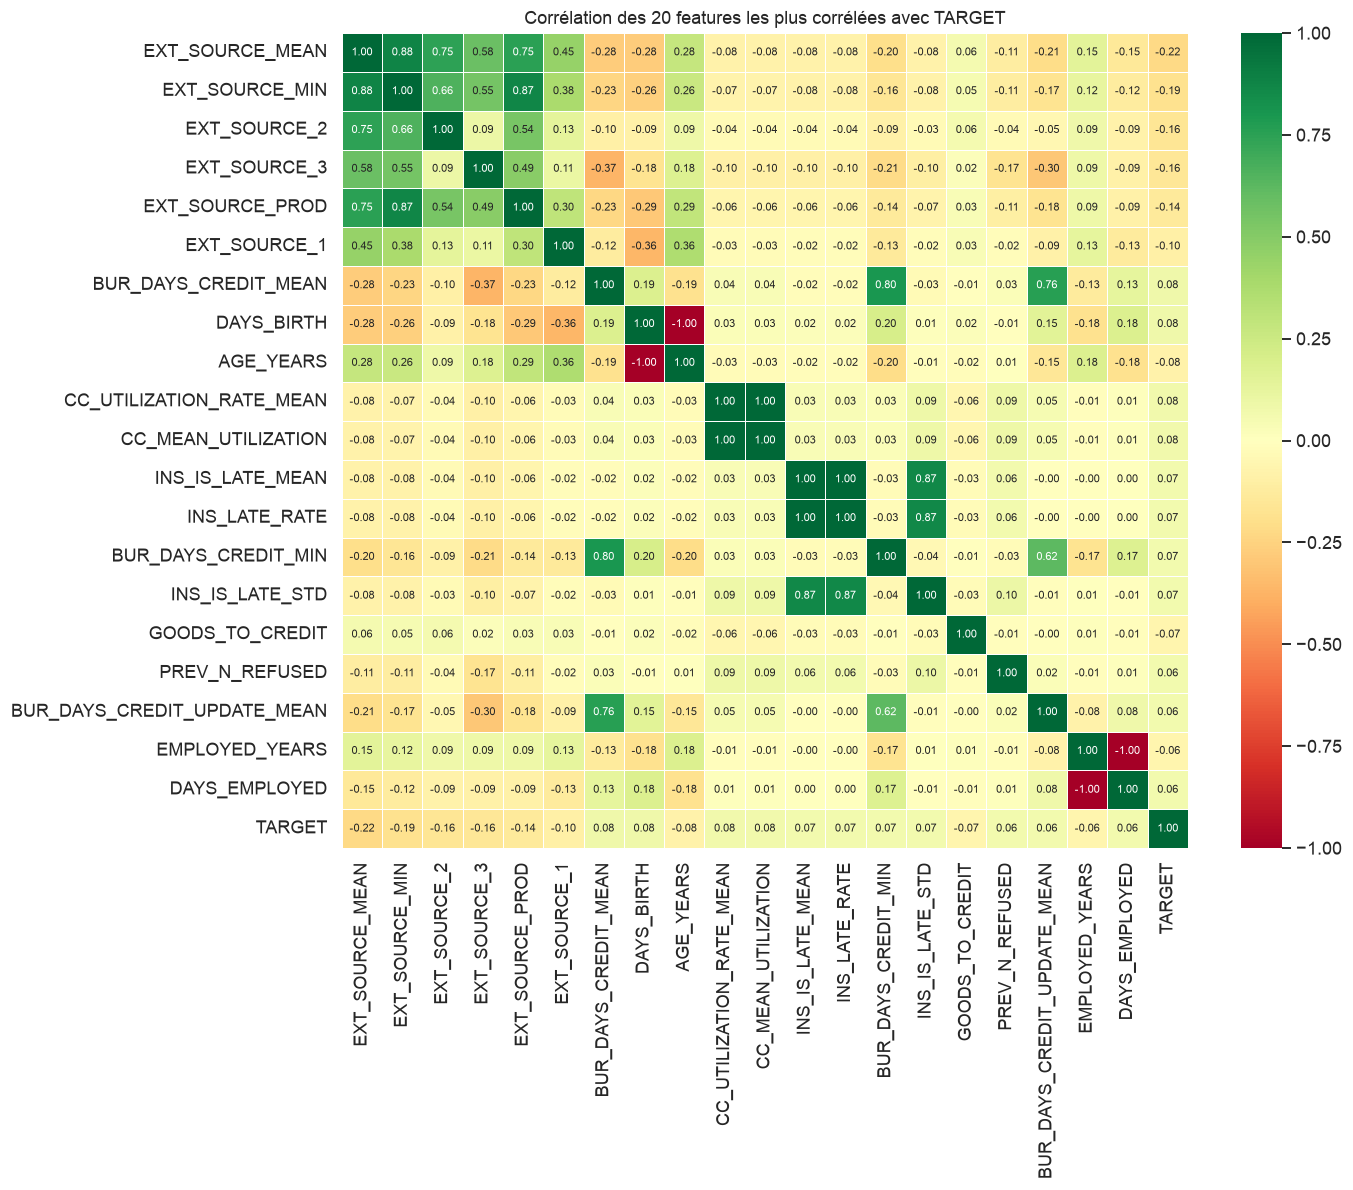

Top 10 features corrélées avec TARGET :
EXT_SOURCE_MEAN         0.222
EXT_SOURCE_MIN          0.185
EXT_SOURCE_2            0.160
EXT_SOURCE_3            0.156
EXT_SOURCE_PROD         0.139
EXT_SOURCE_1            0.099
BUR_DAYS_CREDIT_MEAN    0.082
DAYS_BIRTH              0.078
AGE_YEARS               0.078
CC_MEAN_UTILIZATION     0.075


In [27]:
# ── Corrélations avec TARGET ──────────────────────────────────────
top_corr_cols = (
    train_imputed.drop(columns=["SK_ID_CURR"], errors="ignore")
    .corr()["TARGET"].drop("TARGET")
    .abs().sort_values(ascending=False)
    .head(20).index.tolist()
)
corr_matrix = train_imputed[top_corr_cols + ["TARGET"]].corr()

fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", center=0,
    cmap="RdYlGn", linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("Corrélation des 20 features les plus corrélées avec TARGET", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "03_correlation_top_features.png"))
plt.show()

print("Top 10 features corrélées avec TARGET :")
corr_target = corr_matrix["TARGET"].drop("TARGET").abs().sort_values(ascending=False)
print(corr_target.head(10).round(3).to_string())


---
## 💾 8. Sauvegarde du dataset final

Les fichiers produits sont directement utilisables par l'étape 2 (modélisation + MLflow).


In [28]:
train_path = os.path.join(OUTPUT_DIR, "train_prepared.csv")
test_path  = os.path.join(OUTPUT_DIR, "test_prepared.csv")

train_imputed.to_csv(train_path, index=False)
test_imputed.to_csv(test_path,  index=False)

print("Fichiers sauvegardés :")
print(f"  ✓ {train_path}")
print(f"  ✓ {test_path}")

# ── Rapport de synthèse ───────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║         RAPPORT — ÉTAPE 1 : Préparation des données         ║
╠══════════════════════════════════════════════════════════════╣""")
print(f"║  Clients (train)      : {train_imputed.shape[0]:>10,}                     ║")
print(f"║  Clients (test)       : {test_imputed.shape[0]:>10,}                     ║")
print(f"║  Features produites   : {train_imputed.shape[1]-2:>10,}                     ║")
print(f"║  Défauts (TARGET=1)   : {int(TARGET.sum()):>10,}  ({TARGET.mean()*100:.1f}%)              ║")
print(f"║  Ratio déséquilibre   :      1 : {int(class_counts[0]/class_counts[1]):<3}                    ║")
print("""╠══════════════════════════════════════════════════════════════╣
║  Tables fusionnées    : 6 (app+bureau+prev+pos+ins+cc)      ║
║  Encodage             : LabelEncoder (bin) + One-Hot (nom)  ║
║  Imputation           : Médiane (fit train → transform test)║
╠══════════════════════════════════════════════════════════════╣
║  Prochaine étape      : Modélisation + MLflow tracking      ║
╚══════════════════════════════════════════════════════════════╝""")


Fichiers sauvegardés :
  ✓ ./output/train_prepared.csv
  ✓ ./output/test_prepared.csv

╔══════════════════════════════════════════════════════════════╗
║         RAPPORT — ÉTAPE 1 : Préparation des données         ║
╠══════════════════════════════════════════════════════════════╣
║  Clients (train)      :    307,511                     ║
║  Clients (test)       :     48,744                     ║
║  Features produites   :        728                     ║
║  Défauts (TARGET=1)   :     24,825  (8.1%)              ║
║  Ratio déséquilibre   :      1 : 11                     ║
╠══════════════════════════════════════════════════════════════╣
║  Tables fusionnées    : 6 (app+bureau+prev+pos+ins+cc)      ║
║  Encodage             : LabelEncoder (bin) + One-Hot (nom)  ║
║  Imputation           : Médiane (fit train → transform test)║
╠══════════════════════════════════════════════════════════════╣
║  Prochaine étape      : Modélisation + MLflow tracking      ║
╚═══════════════════════════════════

---
## Validation par StratifiedKFold 5 folds

Avant de passer à la modélisation, on vérifie que le dataset est **stable et équilibré** sur 5 folds.
Chaque fold doit conserver le même ratio de défauts (~8.1%) — c'est la garantie que la cross-validation sera fiable en étape 2.

In [29]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# ── Préparation ───────────────────────────────────────────────────
X = train_imputed.drop(columns=["SK_ID_CURR", "TARGET"])
y = train_imputed["TARGET"]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Validation StratifiedKFold — 5 folds")
print("-" * 55)
print(f"{'Fold':<6} {'Clients train':>14} {'Clients val':>12} {'% défauts train':>16} {'% défauts val':>14}")
print("-" * 55)

fold_stats = []
for fold, (idx_train, idx_val) in enumerate(skf.split(X, y), 1):
    y_tr  = y.iloc[idx_train]
    y_val = y.iloc[idx_val]

    pct_train = y_tr.mean() * 100
    pct_val   = y_val.mean() * 100

    fold_stats.append({
        "fold"      : fold,
        "n_train"   : len(y_tr),
        "n_val"     : len(y_val),
        "pct_train" : pct_train,
        "pct_val"   : pct_val,
    })
    print(f"  {fold:<4} {len(y_tr):>14,} {len(y_val):>12,} {pct_train:>15.2f}% {pct_val:>13.2f}%")

print("-" * 55)

pcts = [s["pct_val"] for s in fold_stats]
print(f"\n  % défauts moyen  : {np.mean(pcts):.2f}%")
print(f"  Écart-type       : {np.std(pcts):.4f}%  ← doit être proche de 0")
print(f"  Min / Max        : {min(pcts):.2f}% / {max(pcts):.2f}%")

if np.std(pcts) < 0.05:
    print("\n  ✅ Stratification parfaite : chaque fold respecte le ratio 8.1%")
else:
    print("\n  ⚠️ Écart-type élevé : vérifier la stratification")

Validation StratifiedKFold — 5 folds
-------------------------------------------------------
Fold    Clients train  Clients val  % défauts train  % défauts val
-------------------------------------------------------
  1           246,008       61,503            8.07%          8.07%
  2           246,009       61,502            8.07%          8.07%
  3           246,009       61,502            8.07%          8.07%
  4           246,009       61,502            8.07%          8.07%
  5           246,009       61,502            8.07%          8.07%
-------------------------------------------------------

  % défauts moyen  : 8.07%
  Écart-type       : 0.0001%  ← doit être proche de 0
  Min / Max        : 8.07% / 8.07%

  ✅ Stratification parfaite : chaque fold respecte le ratio 8.1%


## Visualisation de la stabilité des folds

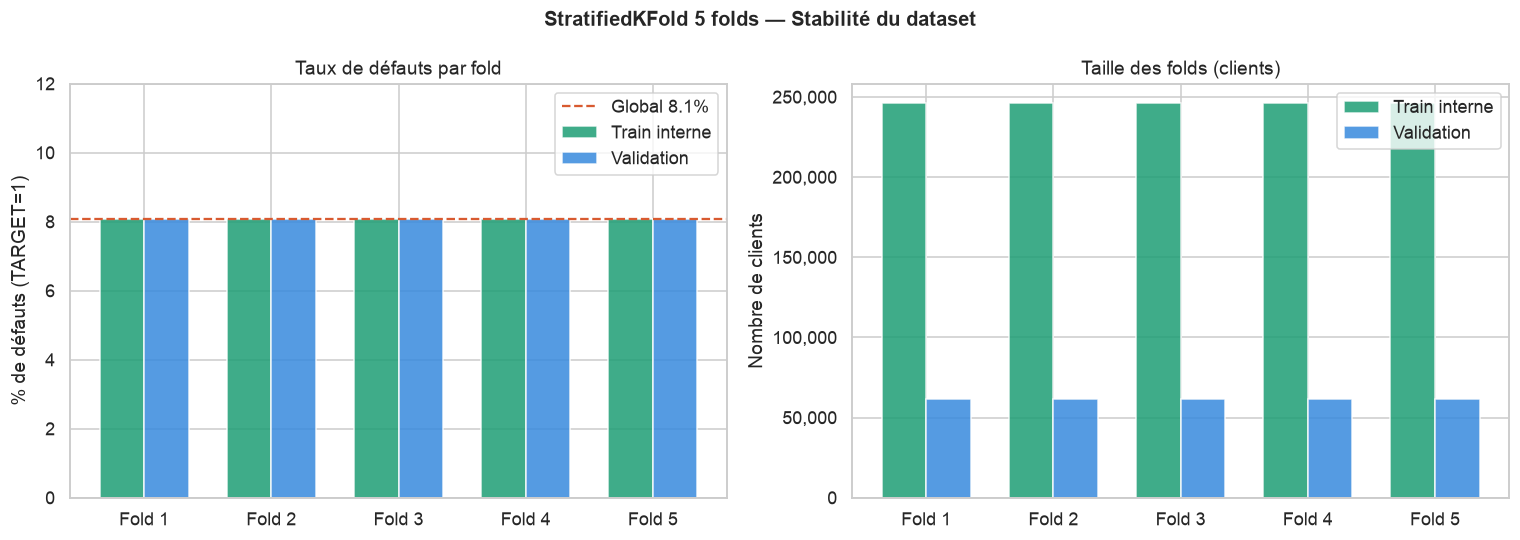

  ✅ Dataset validé — prêt pour l'étape 2 : Modélisation + MLflow


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("StratifiedKFold 5 folds — Stabilité du dataset", fontsize=13, fontweight="bold")

folds      = [s["fold"]      for s in fold_stats]
pcts_train = [s["pct_train"] for s in fold_stats]
pcts_val   = [s["pct_val"]   for s in fold_stats]
n_trains   = [s["n_train"]   for s in fold_stats]
n_vals     = [s["n_val"]     for s in fold_stats]

# ── % défauts par fold ────────────────────────────────────────────
x = np.arange(len(folds))
w = 0.35
axes[0].bar(x - w/2, pcts_train, width=w, label="Train interne", color="#1D9E75", alpha=0.85)
axes[0].bar(x + w/2, pcts_val,   width=w, label="Validation",    color="#378ADD", alpha=0.85)
axes[0].axhline(y.mean()*100, color="#D85A30", ls="--", lw=1.5, label=f"Global {y.mean()*100:.1f}%")
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"Fold {f}" for f in folds])
axes[0].set_ylabel("% de défauts (TARGET=1)")
axes[0].set_title("Taux de défauts par fold")
axes[0].set_ylim(0, 12)
axes[0].legend()

# ── Taille des folds ──────────────────────────────────────────────
axes[1].bar(x - w/2, n_trains, width=w, label="Train interne", color="#1D9E75", alpha=0.85)
axes[1].bar(x + w/2, n_vals,   width=w, label="Validation",    color="#378ADD", alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Fold {f}" for f in folds])
axes[1].set_ylabel("Nombre de clients")
axes[1].set_title("Taille des folds (clients)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "05_stratified_kfold.png"))
plt.show()
print("  ✅ Dataset validé — prêt pour l'étape 2 : Modélisation + MLflow")